In [1]:
import pandas as pd
import numpy as np
dfe = pd.read_csv('Mobile Reviews Sentiment Encoded.csv')
df_clean = pd.read_csv('Mobile Reviews Sentiment Cleaned.csv')

**Scaling**

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(dfe)

print(scaled_data.shape)

(50000, 25)


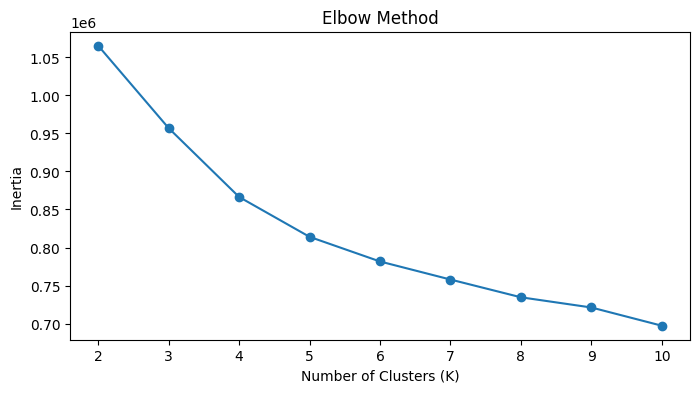

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

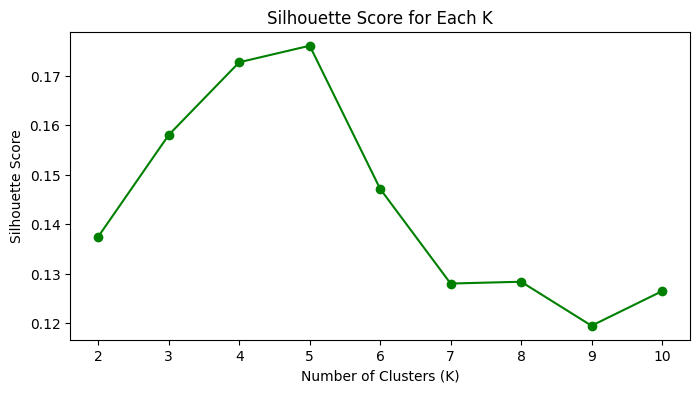

In [12]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

**Sentiment Clustering**

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [8]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
dfe['cluster'] = km_final.fit_predict(scaled_data)

print("Cluster distribution:")
print(dfe['cluster'].value_counts())

Cluster distribution:
cluster
0    23398
2    20478
1     6124
Name: count, dtype: int64


In [9]:
df_clean = pd.read_csv('Mobile Reviews Sentiment Cleaned.csv')
df_clean['cluster'] = dfe['cluster']

cluster_summary = df_clean.groupby('cluster').agg({
    'rating': 'mean',
    'price_usd': 'mean',
    'battery_life_rating': 'mean',
    'camera_rating': 'mean',
    'performance_rating': 'mean',
    'sentiment': lambda x: x.value_counts().index[0],  # most common sentiment
    'brand': lambda x: x.value_counts().index[0]       # most common brand
}).round(2)

print(cluster_summary)

         rating  price_usd  battery_life_rating  camera_rating  performance_rating sentiment   brand
cluster                                                                                             
0          4.02     689.17                 3.59           3.58                3.58  Positive  Realme
1          3.11     688.89                 2.69           2.72                2.74  Positive  Google
2          2.09     690.78                 1.73           1.73                1.74   Neutral  Xiaomi


In [10]:
cluster_labels = {
    0: 'Happy Users',
    1: 'Unhappy Users',
    2: 'Average Users'
}

df_clean['cluster_label'] = df_clean['cluster'].map(cluster_labels)

print('Cluster Label Distribution:')
print(df_clean['cluster_label'].value_counts())

Cluster Label Distribution:
cluster_label
Happy Users      23398
Average Users    20478
Unhappy Users     6124
Name: count, dtype: int64


In [2]:
dfe.head()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,...,language_encoded,sentiment_encoded,lang_English,lang_German,lang_Hindi,lang_Portuguese,verified_purchase_encoded,country_encoded,review_year,review_month
0,1,45,337.31,83.00,2.0,1,1,3,2,1,...,2,0,0,0,1,0,1,4,2023,11
1,2,18,307.78,5.70,4.0,3,2,4,3,2,...,3,2,0,0,0,1,1,1,2023,3
2,3,27,864.53,83.00,4.0,3,5,3,2,4,...,2,2,0,0,1,0,1,4,2022,12
3,4,19,660.94,3.67,3.0,1,3,2,1,2,...,0,2,1,0,0,0,0,5,2025,3
4,5,38,792.13,5.70,3.0,3,3,2,2,1,...,3,1,0,0,0,1,1,1,2023,9


**----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

In [15]:
# Interpretation of each cluster
for label in ['Happy Users', 'Average Users', 'Unhappy Users']:
    cluster_df = df_clean[df_clean['cluster_label'] == label]
    avg_rating = cluster_df['rating'].mean().round(2)
    avg_price = cluster_df['price_usd'].mean().round(2)
    avg_battery = cluster_df['battery_life_rating'].mean().round(2)
    avg_camera = cluster_df['camera_rating'].mean().round(2)
    avg_perf = cluster_df['performance_rating'].mean().round(2)
    top_sentiment = cluster_df['sentiment'].value_counts().index[0]
    top_brand = cluster_df['brand'].value_counts().index[0]

    print(f"\n{'='*40}")
    print(f"Cluster: {label}")
    print(f"  Rows        : {cluster_df.shape[0]}")
    print(f"  Avg Rating  : {avg_rating}")
    print(f"  Avg Price   : ${avg_price}")
    print(f"  Battery     : {avg_battery}")
    print(f"  Camera      : {avg_camera}")
    print(f"  Performance : {avg_perf}")
    print(f"  Top Sentiment: {top_sentiment}")
    print(f"  Top Brand   : {top_brand}")


Cluster: Happy Users
  Rows        : 23398
  Avg Rating  : 4.02
  Avg Price   : $689.17
  Battery     : 3.59
  Camera      : 3.58
  Performance : 3.58
  Top Sentiment: Positive
  Top Brand   : Realme

Cluster: Average Users
  Rows        : 20478
  Avg Rating  : 2.09
  Avg Price   : $690.78
  Battery     : 1.73
  Camera      : 1.73
  Performance : 1.74
  Top Sentiment: Neutral
  Top Brand   : Xiaomi

Cluster: Unhappy Users
  Rows        : 6124
  Avg Rating  : 3.11
  Avg Price   : $688.89
  Battery     : 2.69
  Camera      : 2.72
  Performance : 2.74
  Top Sentiment: Positive
  Top Brand   : Google


Sentiment Distribution per Cluster:
sentiment      Negative  Neutral  Positive
cluster_label                             
Average Users      8808     8842      2828
Happy Users         106     2230     21062
Unhappy Users      1243     1567      3314


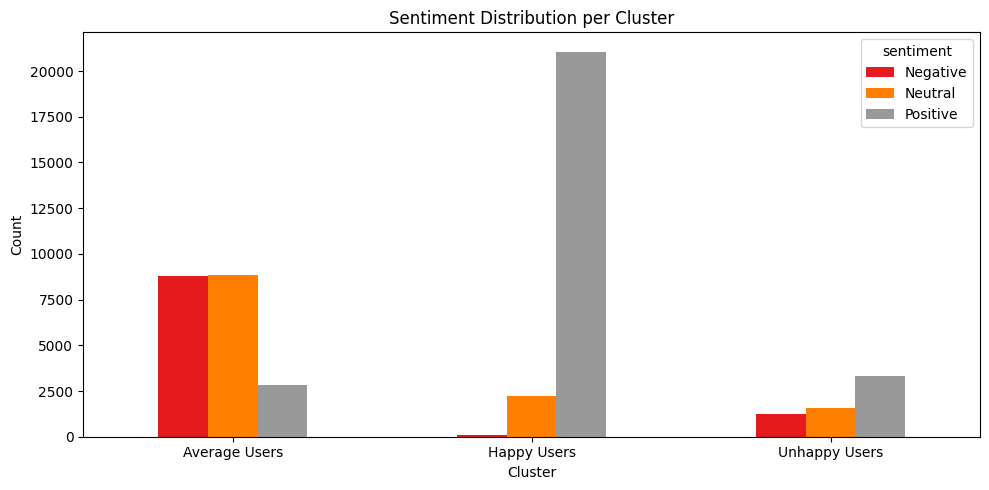

In [20]:
# Sentiment breakdown per cluster
sentiment_dist = df_clean.groupby(['cluster_label', 'sentiment']).size().unstack(fill_value=0)
print("Sentiment Distribution per Cluster:")
print(sentiment_dist)

sentiment_dist.plot(kind='bar', figsize=(10, 5), colormap='Set1')
plt.title('Sentiment Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Top 3 brands per cluster
print("Top Brands in Each Cluster:")
for label in df_clean['cluster_label'].unique():
    print(f"\n{label}:")
    print(df_clean[df_clean['cluster_label'] == label]['brand'].value_counts().head(3))

Top Brands in Each Cluster:

Unhappy Users:
brand
Google     918
Samsung    891
Realme     876
Name: count, dtype: int64

Happy Users:
brand
Realme     3407
OnePlus    3400
Google     3370
Name: count, dtype: int64

Average Users:
brand
Xiaomi    3030
Google    2946
Apple     2928
Name: count, dtype: int64


In [23]:
# Deep Cluster Analysis - Understanding each cluster fully

for label in ['Happy Users', 'Average Users', 'Unhappy Users']:
    c = df_clean[df_clean['cluster_label'] == label]
    
    print(f"\n{'='*60}")
    print(f"  CLUSTER: {label}")
    print(f"  Total Rows: {c.shape[0]} | Total Columns: {c.shape[1]}")
    print(f"{'='*60}")
    
    # Numeric averages
    print("\n>> Average Ratings & Price:")
    num_cols = ['rating', 'price_usd', 'battery_life_rating', 'camera_rating', 'performance_rating']
    for col in num_cols:
        if col in c.columns:
            print(f"   {col:25s}: {c[col].mean():.2f}")
    
    # Top brands
    print("\n>> Top 5 Brands:")
    print(c['brand'].value_counts().head(5).to_string())
    
    # Source breakdown (if column exists)
    if 'source' in c.columns:
        print("\n>> Top 5 Sources:")
        print(c['source'].value_counts().head(5).to_string())
    
    # Sentiment breakdown
    print("\n>> Sentiment Breakdown:")
    print(c['sentiment'].value_counts().to_string())
    
    # Sample reviews (if column exists)
    if 'review_text' in c.columns:
        print("\n>> Sample Reviews (3 rows):")
        samples = c[['brand', 'rating', 'review_text']].sample(3, random_state=42)
        for _, row in samples.iterrows():
            print(f"   Brand: {row['brand']} | Rating: {row['rating']}")
            print(f"   Review: {str(row['review_text'])[:120]}")
            print()
    
    # Price range
    print(f"\n>> Price Range: Min=${c['price_usd'].min():.2f}  |  Max=${c['price_usd'].max():.2f}  |  Avg=${c['price_usd'].mean():.2f}")
    
    # Rating range
    print(f">> Rating Range: Min={c['rating'].min():.2f}  |  Max={c['rating'].max():.2f}  |  Avg={c['rating'].mean():.2f}")


  CLUSTER: Happy Users
  Total Rows: 23398 | Total Columns: 23

>> Average Ratings & Price:
   rating                   : 4.02
   price_usd                : 689.17
   battery_life_rating      : 3.59
   camera_rating            : 3.58
   performance_rating       : 3.58

>> Top 5 Brands:
brand
Realme     3407
OnePlus    3400
Google     3370
Xiaomi     3350
Apple      3341

>> Top 5 Sources:
source
eBay          5540
AliExpress    4530
Amazon        4522
BestBuy       4419
Flipkart      4387

>> Sentiment Breakdown:
sentiment
Positive    21062
Neutral      2230
Negative      106

>> Price Range: Min=$180.12  |  Max=$1499.89  |  Avg=$689.17
>> Rating Range: Min=2.00  |  Max=5.00  |  Avg=4.02

  CLUSTER: Average Users
  Total Rows: 20478 | Total Columns: 23

>> Average Ratings & Price:
   rating                   : 2.09
   price_usd                : 690.78
   battery_life_rating      : 1.73
   camera_rating            : 1.73
   performance_rating       : 1.74

>> Top 5 Brands:
brand
Xiaomi